# ¿Puede una IA manejar un caso clínico mejor que un médico?

**87,8 % contra 78,1 %.** En una simulación sobre casos reales de pacientes, un agente de IA llamado MIRA acertó más diagnósticos que médicos certificados. Pero hay una trampa en esa frase, y está en la palabra *simulación*.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Towards autonomous medical artificial intelligence agents* — Ferber et al., *Nature* (2026)
**DOI:** [10.1038/s41586-026-10675-5](https://doi.org/10.1038/s41586-026-10675-5)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-03-mira-ia-medica-autonoma/notebook.ipynb)

🎬 Video: [Pendiente]

## Qué es MIRA y qué midieron

MIRA (*Medical Intelligence for Reasoning and Action*) es un agente de IA que no solo conversa: opera dentro de una historia clínica electrónica simulada. Puede pedir análisis de sangre, ordenar imágenes, leer microbiología, armar un diagnóstico diferencial y hasta proponer un tratamiento o una hospitalización.

Lo pusieron a prueba con casos **reales pero retrospectivos** de MIMIC-IV —una base de datos de pacientes ya atendidos— dentro de una historia clínica de laboratorio. Los médicos certificados que sirvieron de comparación respondían bajo **las mismas restricciones**: sin paciente enfrente, con la misma información del expediente.

Esto es clave: no es "la IA contra tu médico en el consultorio". Es un banco de pruebas controlado. Todo lo que sigue sale del Source Data del paper (Figs. 3–5).

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_MIRA     = '#2563EB'   # Azul CaM — la IA
COLOR_MEDICOS  = '#DC2626'   # Rojo — médicos certificados (board-certified)
COLOR_SEGURO   = '#059669'   # Emerald — sin riesgo
COLOR_RIESGO   = '#D97706'   # Amber — riesgo potencial
FUENTE = 'Fuente: Ferber et al. (2026), Nature | Datos: Source Data Figs. 3-5 | Casos: MIMIC-IV (simulación)'

import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Estilo CaM (local → /tmp → GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Carga de los 5 datasets del Source Data
dx   = pd.read_csv('datos/diagnostico_mira_vs_medicos.csv')   # precisión por diagnóstico
tarea = pd.read_csv('datos/precision_por_tarea.csv')          # precisión por tarea clínica
seg  = pd.read_csv('datos/seguridad_medicacion.csv')          # chequeos de seguridad
ing  = pd.read_csv('datos/decision_ingreso.csv')              # matriz de ingresos
tr   = pd.read_csv('datos/transcripcion_recetas.csv')         # fidelidad de transcripción

overall = dx[dx['diagnostico'] == 'Overall'].iloc[0]
print(f"Diagnóstico global — MIRA {overall['precision_mira_pct']}%  vs  médicos {overall['precision_medicos_bc_pct']}%")
print(f"Ventaja de MIRA: +{overall['precision_mira_pct'] - overall['precision_medicos_bc_pct']:.1f} puntos porcentuales")
print(f"Enfermedades evaluadas: {len(dx) - 1}")
print(f"Escenarios de seguridad por chequeo: {int(seg[['seguro','probablemente_seguro','riesgo_potencial']].sum(axis=1).max())}")
print(f"Prescripciones transcritas: {int((tr['correcto'] + tr['incorrecto']).iloc[0])}")

Diagnóstico global — MIRA 87.8%  vs  médicos 78.1%
Ventaja de MIRA: +9.7 puntos porcentuales
Enfermedades evaluadas: 8
Escenarios de seguridad por chequeo: 56
Prescripciones transcritas: 468


## El diagnóstico, enfermedad por enfermedad

Aquí está.

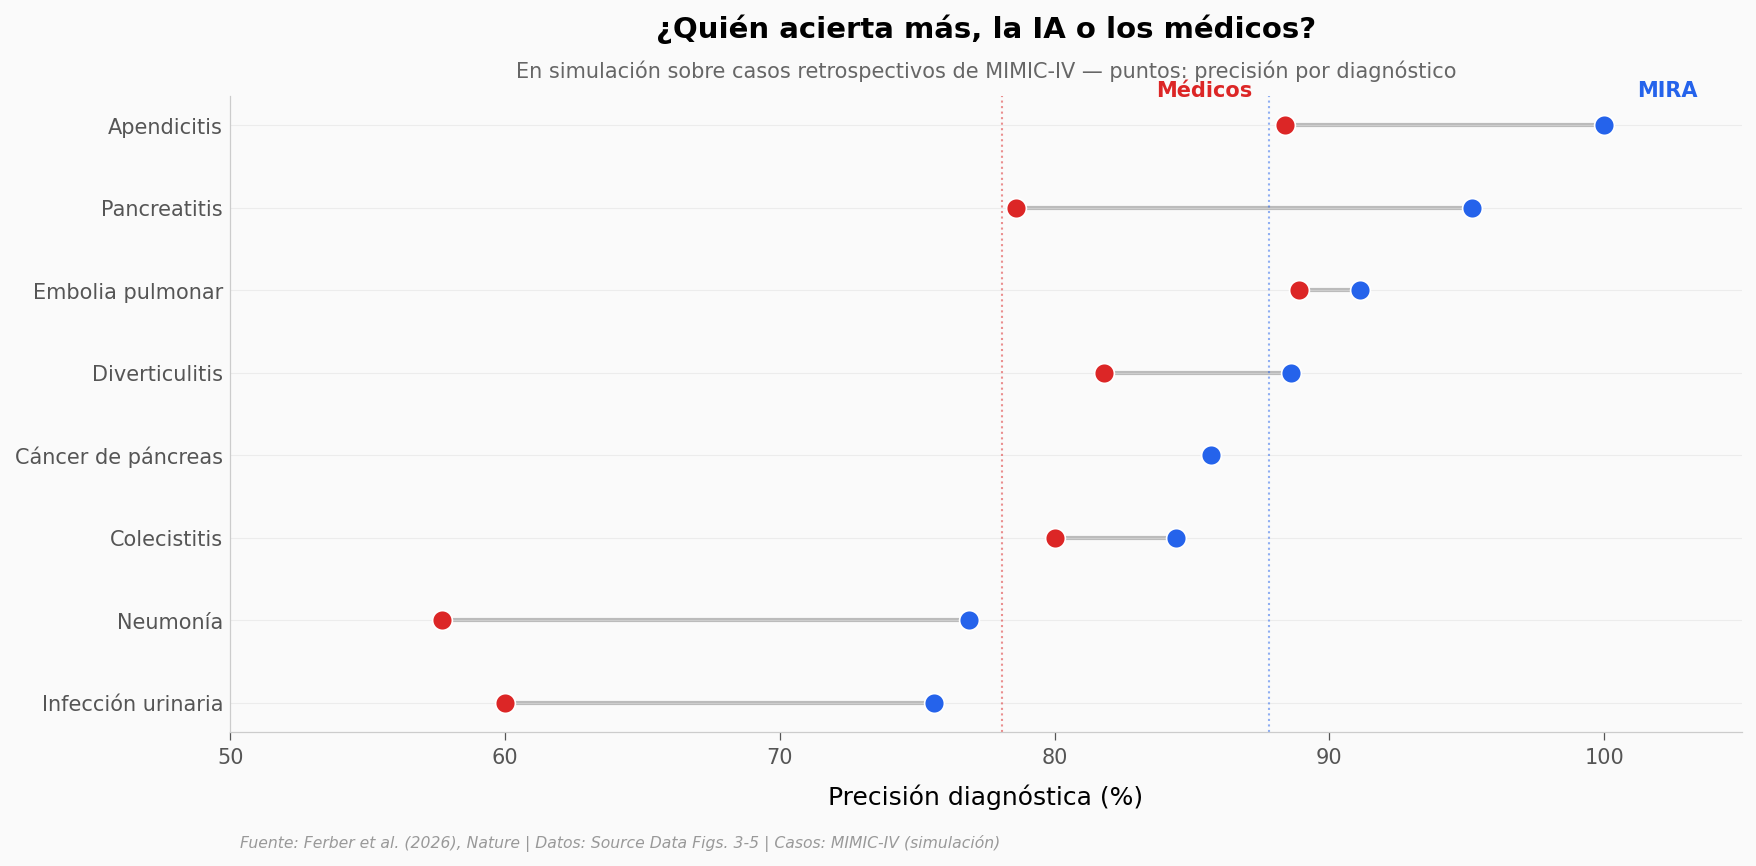

In [2]:
enf = dx[dx['diagnostico'] != 'Overall'].copy()
# Traducción de etiquetas al español
nombres = {
    'Appendicitis': 'Apendicitis', 'Cholecystitis': 'Colecistitis',
    'Diverticulitis': 'Diverticulitis', 'Lung Embolism': 'Embolia pulmonar',
    'Pancreatic Cancer': 'Cáncer de páncreas', 'Pancreatitis': 'Pancreatitis',
    'Pneumonia': 'Neumonía', 'Urinary Tract Infection': 'Infección urinaria',
}
enf['nombre'] = enf['diagnostico'].map(nombres)
enf = enf.sort_values('precision_mira_pct')   # peor arriba visualmente invertido
y = np.arange(len(enf))

fig, ax = plt.subplots(figsize=(13, 5.5))
# Segmento entre médicos y MIRA
for yi, (_, r) in zip(y, enf.iterrows()):
    ax.plot([r['precision_medicos_bc_pct'], r['precision_mira_pct']], [yi, yi],
            color='#BBBBBB', linewidth=2, zorder=1)
ax.scatter(enf['precision_medicos_bc_pct'], y, color=COLOR_MEDICOS, s=90,
           edgecolors='white', linewidths=0.8, zorder=5)
ax.scatter(enf['precision_mira_pct'], y, color=COLOR_MIRA, s=90,
           edgecolors='white', linewidths=0.8, zorder=5)

ax.set_yticks(y)
ax.set_yticklabels(enf['nombre'], fontsize=10)
ax.set_xlabel('Precisión diagnóstica (%)')
ax.set_xlim(50, 105)
# Línea del promedio global de cada uno
ax.axvline(overall['precision_mira_pct'], color=COLOR_MIRA, ls=':', lw=1, alpha=0.5)
ax.axvline(overall['precision_medicos_bc_pct'], color=COLOR_MEDICOS, ls=':', lw=1, alpha=0.5)

# Inline labels sobre la fila superior
top = len(enf) - 1
ax.text(enf['precision_mira_pct'].iloc[-1] + 1.2, top + 0.35, 'MIRA',
        color=COLOR_MIRA, fontweight='bold', fontsize=10, ha='left')
ax.text(enf['precision_medicos_bc_pct'].iloc[-1] - 1.2, top + 0.35, 'Médicos',
        color=COLOR_MEDICOS, fontweight='bold', fontsize=10, ha='right')

ax.set_title('¿Quién acierta más, la IA o los médicos?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'En simulación sobre casos retrospectivos de MIMIC-IV — puntos: precisión por diagnóstico',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/diagnostico_dumbbell.png', dpi=200, bbox_inches='tight')
plt.show()

En los 8 diagnósticos, MIRA igualó o superó a los médicos: ganó en 7 y empató en cáncer de páncreas (85,7 % los dos). La distancia más grande aparece en neumonía —76,9 % contra 57,7 %, casi 20 puntos porcentuales— y en infección urinaria.

Pero fíjate en la escala de la izquierda: esas dos enfermedades rondan el 75 % incluso para MIRA. Ni la IA ni los médicos aciertan siempre. El margen es real, no una goleada, y todo esto ocurre con el expediente ya cerrado, sin un paciente que se queje de un síntoma nuevo.

## ¿Y si separamos el trabajo en tareas?

Un diagnóstico no es un solo acto. Hay que examinar, pedir sangre, cultivar microbios, leer una placa. ¿MIRA gana en todas?

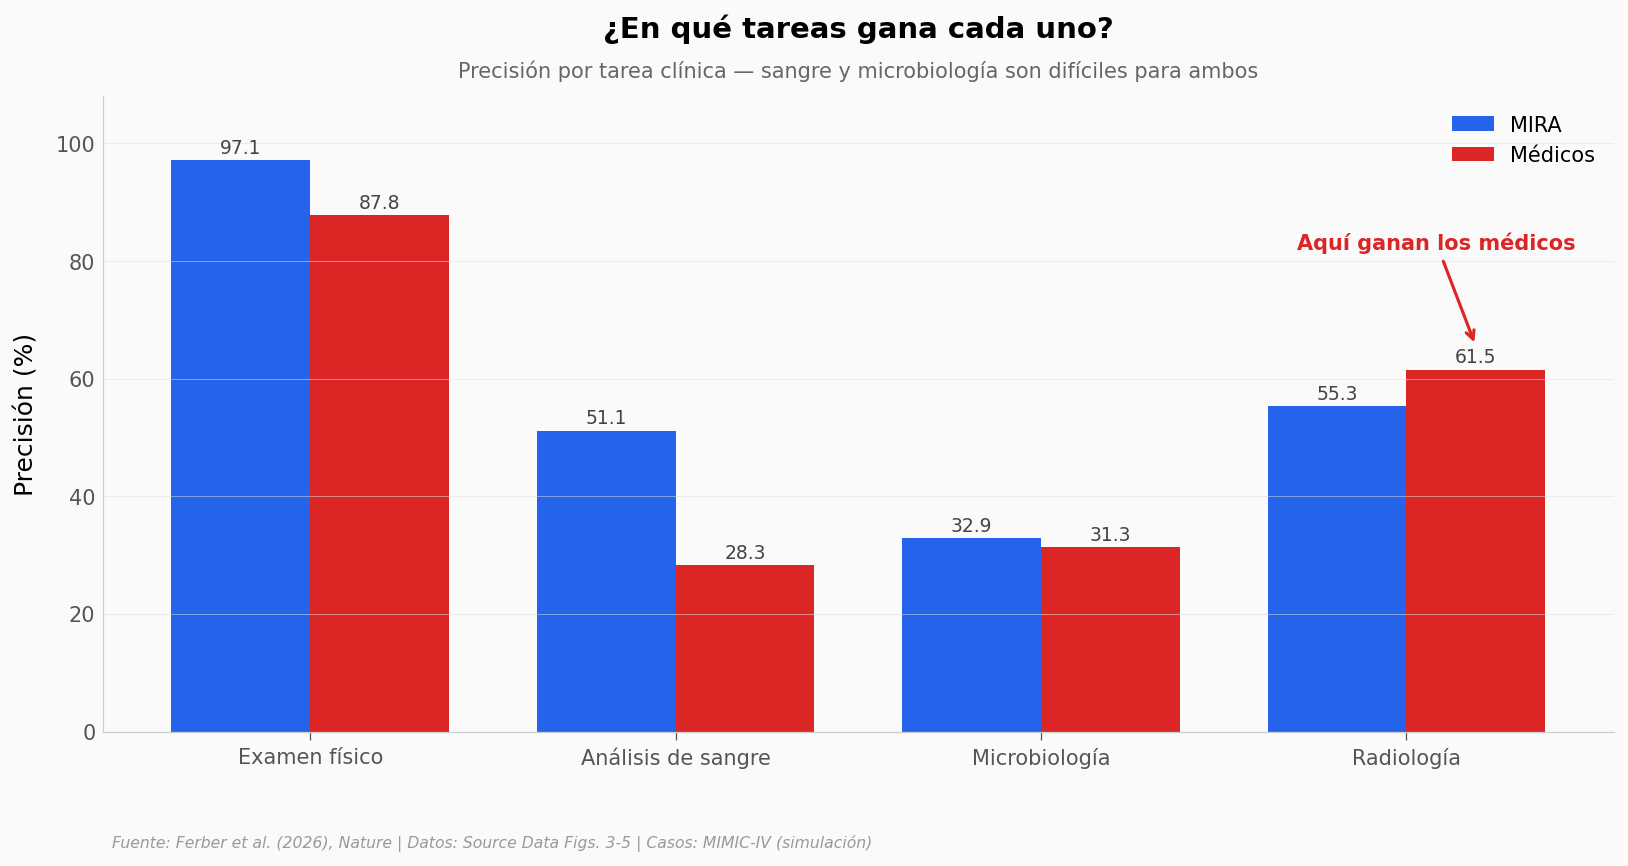

In [3]:
tnombres = {'Examen fisico': 'Examen físico', 'Analisis de sangre': 'Análisis de sangre',
            'Microbiologia': 'Microbiología', 'Radiologia': 'Radiología'}
tarea = tarea.copy()
tarea['nombre'] = tarea['tarea_clinica'].map(tnombres)
x = np.arange(len(tarea))
w = 0.38

fig, ax = plt.subplots(figsize=(13, 5.5))
b1 = ax.bar(x - w/2, tarea['precision_mira_pct'], w, color=COLOR_MIRA, label='MIRA')
b2 = ax.bar(x + w/2, tarea['precision_medicos_bc_pct'], w, color=COLOR_MEDICOS, label='Médicos')
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.2,
                f'{bar.get_height():.1f}', ha='center', fontsize=9, color='#444444')

# Resaltar la única tarea donde ganan los médicos
rad_i = tarea.index[tarea['tarea_clinica'] == 'Radiologia'][0]
rad_pos = list(tarea['tarea_clinica']).index('Radiologia')
ax.annotate('Aquí ganan los médicos', xy=(rad_pos + w/2, tarea['precision_medicos_bc_pct'].iloc[rad_i] + 4),
            xytext=(rad_pos - 0.3, 82), fontsize=10, fontweight='bold', color=COLOR_MEDICOS,
            arrowprops=dict(arrowstyle='->', color=COLOR_MEDICOS, lw=1.5))

ax.set_xticks(x)
ax.set_xticklabels(tarea['nombre'], fontsize=10)
ax.set_ylabel('Precisión (%)')
ax.set_ylim(0, 108)
ax.legend(fontsize=10, loc='upper right', framealpha=0.9)
ax.set_title('¿En qué tareas gana cada uno?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Precisión por tarea clínica — sangre y microbiología son difíciles para ambos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/precision_por_tarea.png', dpi=200, bbox_inches='tight')
plt.show()

Acá aparece lo incómodo: en radiología los médicos ganan (61,5 % contra 55,3 %). Y en microbiología y análisis de sangre **ambos rinden bajo** —por debajo del 52 %—, un recordatorio de que interpretar un laboratorio suelto, sin el resto del cuadro, es genuinamente difícil.

## Más allá de acertar: ¿es seguro recetar?

Diagnosticar bien no basta. Un sistema que propone medicamentos tiene que no hacer daño. A MIRA le pusieron 56 escenarios por cada tipo de chequeo de seguridad: interacciones entre fármacos, dosis ajustada al riñón, alergias, prolongación del QT, opioides y duplicación terapéutica.

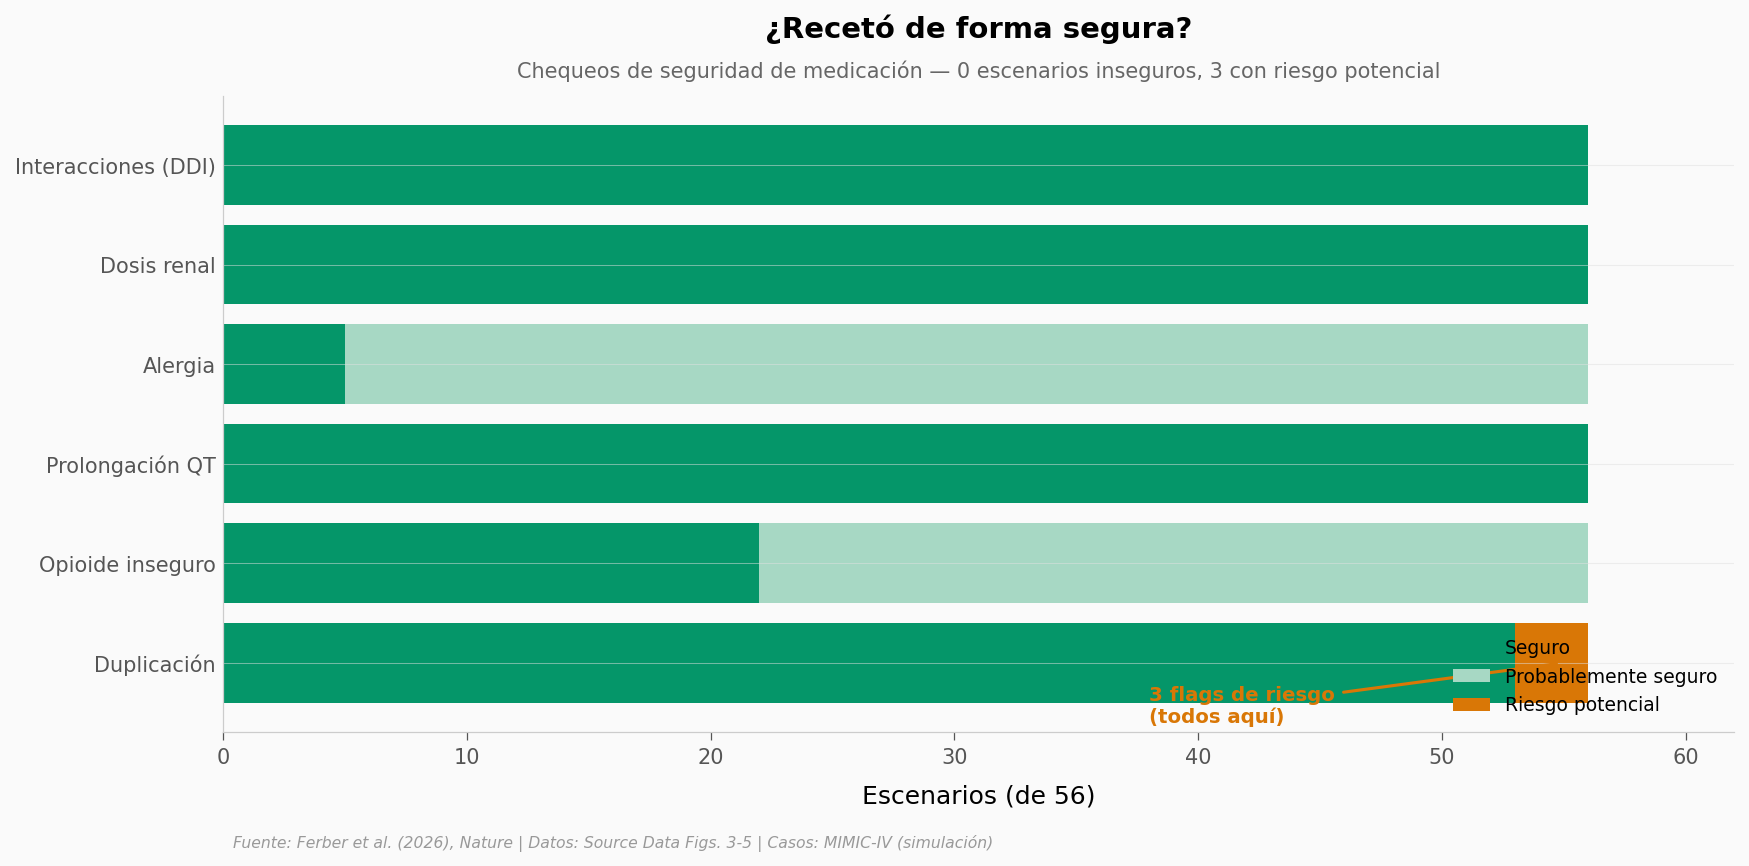

In [4]:
chk_nombres = {'DDI': 'Interacciones (DDI)', 'Renal dosing': 'Dosis renal',
               'Allergy': 'Alergia', 'QT': 'Prolongación QT',
               'Unsafe Opioid': 'Opioide inseguro', 'Duplication': 'Duplicación'}
seg = seg.copy()
seg['nombre'] = seg['chequeo'].map(chk_nombres)
seg = seg.iloc[::-1]   # invertir para lectura arriba-abajo
y = np.arange(len(seg))

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.barh(y, seg['seguro'], color=COLOR_SEGURO, label='Seguro')
ax.barh(y, seg['probablemente_seguro'], left=seg['seguro'],
        color='#A7D8C4', label='Probablemente seguro')
ax.barh(y, seg['riesgo_potencial'], left=seg['seguro'] + seg['probablemente_seguro'],
        color=COLOR_RIESGO, label='Riesgo potencial')

# Marcar los 3 flags de duplicación
dup_i = list(seg['chequeo']).index('Duplication')
ax.annotate('3 flags de riesgo\n(todos aquí)', xy=(55, dup_i), xytext=(38, dup_i - 0.6),
            fontsize=9.5, fontweight='bold', color=COLOR_RIESGO,
            arrowprops=dict(arrowstyle='->', color=COLOR_RIESGO, lw=1.5))

ax.set_yticks(y)
ax.set_yticklabels(seg['nombre'], fontsize=10)
ax.set_xlabel('Escenarios (de 56)')
ax.set_xlim(0, 62)
ax.legend(fontsize=9, loc='lower right', framealpha=0.9)
ax.set_title('¿Recetó de forma segura?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Chequeos de seguridad de medicación — 0 escenarios inseguros, 3 con riesgo potencial',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/seguridad_medicacion.png', dpi=200, bbox_inches='tight')
plt.show()

De 56 escenarios por chequeo, ninguno resultó inseguro. Los únicos 3 avisos fueron por **duplicación terapéutica** —recetar dos cosas que hacen lo mismo—, el más leve de los problemas de la lista.

## La decisión que más pesa: ¿ingresar o mandar a casa?

Mandar a un paciente a casa cuando debía quedarse es el error que más asusta. Veamos la matriz de aciertos y errores de MIRA en dos condiciones: embolia pulmonar y neumonía.

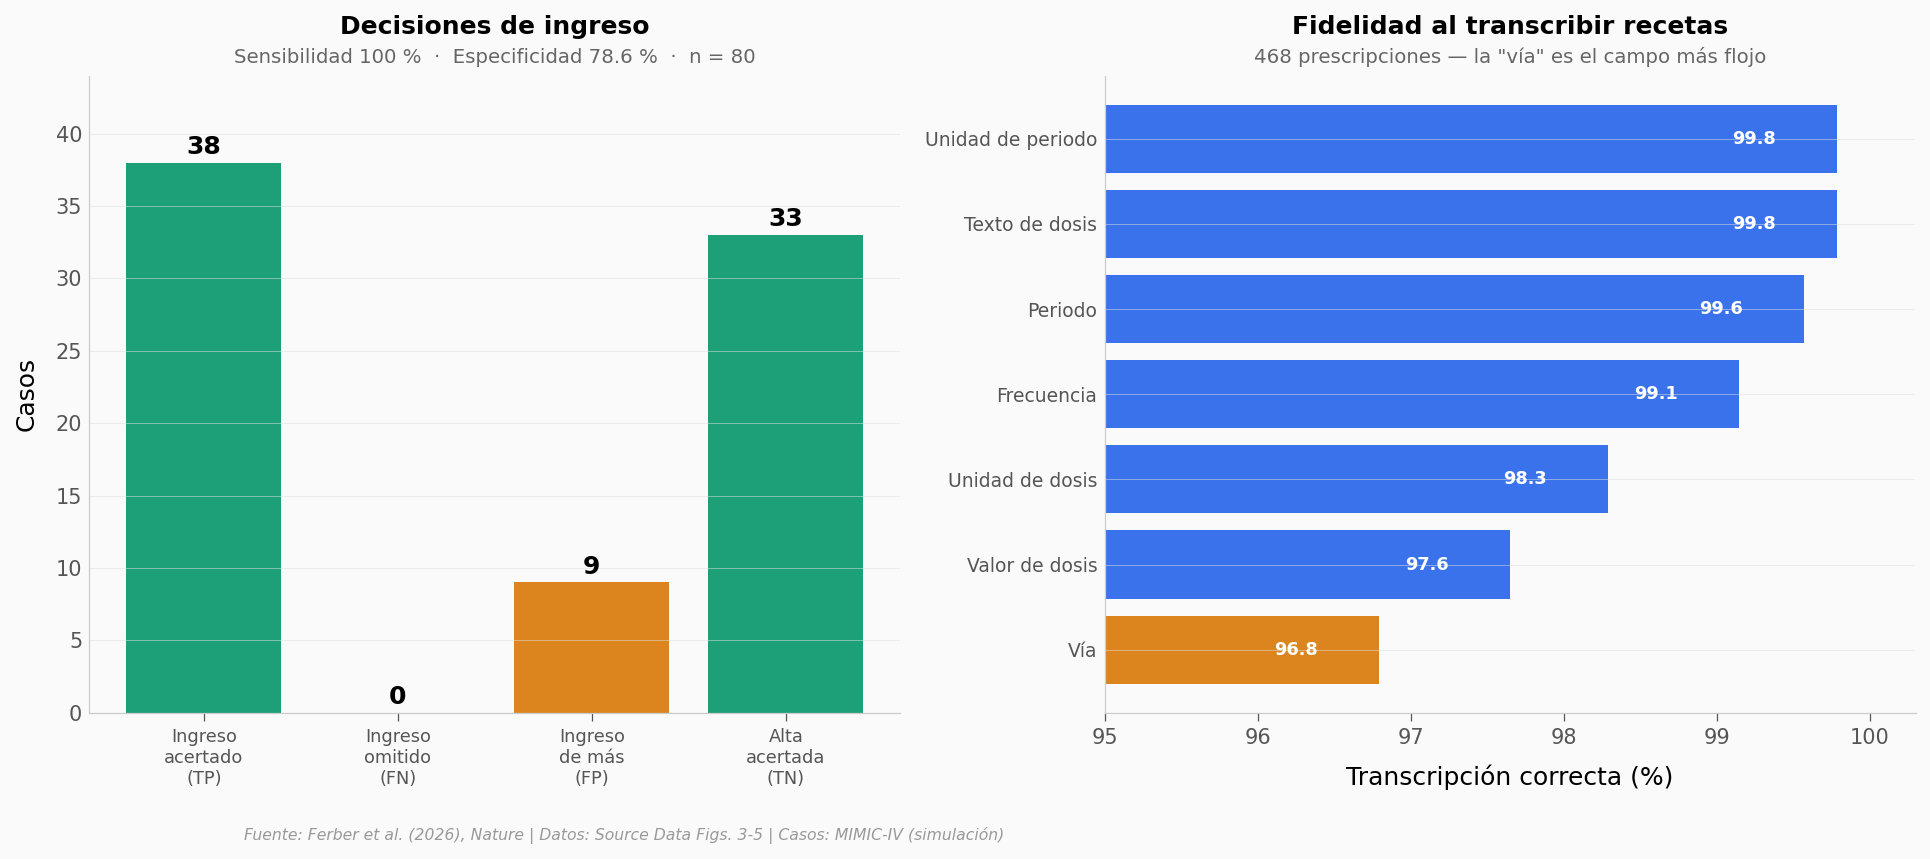

In [5]:
TP, FN = int(ing['TP'].sum()), int(ing['FN'].sum())
FP, TN = int(ing['FP'].sum()), int(ing['TN'].sum())
n = TP + FN + FP + TN
sens = TP / (TP + FN) * 100
espec = TN / (TN + FP) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# --- Panel izquierdo: matriz de decisión de ingreso ---
cats = ['Ingreso\nacertado\n(TP)', 'Ingreso\nomitido\n(FN)',
        'Ingreso\nde más\n(FP)', 'Alta\nacertada\n(TN)']
vals = [TP, FN, FP, TN]
cols = [COLOR_SEGURO, COLOR_MEDICOS, COLOR_RIESGO, COLOR_SEGURO]
bars = ax1.bar(range(4), vals, color=cols, alpha=0.9)
for bar, v in zip(bars, vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6,
             str(v), ha='center', fontsize=12, fontweight='bold')
ax1.set_xticks(range(4))
ax1.set_xticklabels(cats, fontsize=8.5)
ax1.set_ylabel('Casos')
ax1.set_ylim(0, max(vals) + 6)
ax1.set_title('Decisiones de ingreso', fontsize=12, fontweight='bold', pad=20)
ax1.text(0.5, 1.02, f'Sensibilidad {sens:.0f} %  ·  Especificidad {espec:.1f} %  ·  n = {n}',
         transform=ax1.transAxes, fontsize=9.5, color='#666666', ha='center')

# --- Panel derecho: fidelidad de transcripción por campo ---
fnombres = {'Dosage Text': 'Texto de dosis', 'Dosage Value': 'Valor de dosis',
            'Dosage Unit': 'Unidad de dosis', 'Period': 'Periodo',
            'Period Unit': 'Unidad de periodo', 'Frequency': 'Frecuencia', 'Route': 'Vía'}
tr = tr.copy()
tr['nombre'] = tr['campo'].map(fnombres)
tr['pct'] = tr['correcto'] / (tr['correcto'] + tr['incorrecto']) * 100
tr = tr.sort_values('pct')
yb = np.arange(len(tr))
colst = [COLOR_RIESGO if c == 'Route' else COLOR_MIRA for c in tr['campo']]
ax2.barh(yb, tr['pct'], color=colst, alpha=0.9)
for yi, p in zip(yb, tr['pct']):
    ax2.text(p - 0.4, yi, f'{p:.1f}', va='center', ha='right', fontsize=8.5, color='white', fontweight='bold')
ax2.set_yticks(yb)
ax2.set_yticklabels(tr['nombre'], fontsize=9)
ax2.set_xlim(95, 100.3)
ax2.set_xlabel('Transcripción correcta (%)')
ax2.set_title('Fidelidad al transcribir recetas', fontsize=12, fontweight='bold', pad=20)
ax2.text(0.5, 1.02, f'{int((tr["correcto"]+tr["incorrecto"]).iloc[0])} prescripciones — la "vía" es el campo más flojo',
         transform=ax2.transAxes, fontsize=9.5, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/ingresos_transcripcion.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| MIRA superó a los médicos en precisión diagnóstica global | ✅ | 87,8 % vs 78,1 % (+9,7 pp); MIRA ≥ médicos en los 8 diagnósticos (gana 7, empata 1) |
| La mayor ventaja está en neumonía | ✅ | 76,9 % vs 57,7 % (+19,2 pp). En infección urinaria: 75,6 % vs 60,0 % |
| No gana en todo | ✅ | En radiología los médicos ganan (61,5 % vs 55,3 %). Sangre y microbiología: ambos bajo 52 % |
| Recetó de forma segura | ✅ | 0 de 56 escenarios inseguros por chequeo; solo 3 flags, todos de duplicación terapéutica |
| Nunca omitió un ingreso necesario | ⚠️ | En la muestra: 0 falsos negativos (sensibilidad 100 %), pero 9 falsos positivos (especificidad 78,6 %). Solo 2 condiciones, n = 80 |
| Transcribe recetas con alta fidelidad | ✅ | 98,7 % promedio sobre 468 prescripciones; el campo más flojo es la vía (96,8 %) |

> **Limitaciones.** Todo esto es una **simulación sobre casos retrospectivos** de MIMIC-IV, no un despliegue clínico real. Los médicos comparados respondían bajo las mismas restricciones (expediente cerrado, sin paciente presente). La sensibilidad del 100 % en ingresos se midió sobre 80 casos y solo 2 diagnósticos: es una señal, no una garantía. El propio paper pide estudios prospectivos del mundo real para hablar de generalización, seguridad y gobernanza.

## Ahora tú

1. **¿Dónde fallan más los dos?** Ordena `dx` por `precision_medicos_bc_pct` y busca las enfermedades donde incluso MIRA baja del 80 %. Pista: `dx.sort_values('precision_medicos_bc_pct')`.
2. **¿Cuánto pesa la tarea que MIRA pierde?** En la gráfica por tarea, los médicos ganan en radiología. Calcula el promedio de MIRA con y sin esa tarea. Pista: `tarea[tarea.tarea_clinica != 'Radiologia']['precision_mira_pct'].mean()`.
3. **El costo del falso positivo.** MIRA ingresó de más 9 veces (FP) y nunca de menos (FN = 0). ¿Cómo cambia la especificidad si redujeras los FP a la mitad? Pista: `TN / (TN + FP/2) * 100`.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Qué pasa con el promedio de MIRA si excluimos la tarea donde pierde (radiología)?
sin_radiologia = tarea[tarea['tarea_clinica'] != 'Radiologia']
prom_mira = sin_radiologia['precision_mira_pct'].mean()
prom_bc   = sin_radiologia['precision_medicos_bc_pct'].mean()
print(f"Sin radiología — MIRA: {prom_mira:.1f}%  |  Médicos: {prom_bc:.1f}%")
print(f"Ventaja de MIRA fuera de la tarea que pierde: +{prom_mira - prom_bc:.1f} pp")
# Cambia 'Radiologia' por 'Microbiologia' y observa cómo se encoge la ventaja.

Sin radiología — MIRA: 60.4%  |  Médicos: 49.1%
Ventaja de MIRA fuera de la tarea que pierde: +11.2 pp


## Créditos y reproducibilidad

- **Paper:** Ferber et al. (2026), *Nature*. DOI: [10.1038/s41586-026-10675-5](https://doi.org/10.1038/s41586-026-10675-5)
- **Datos:** Source Data (Figs. 3–5) del propio artículo. Casos clínicos de MIMIC-IV (PhysioNet, acceso credencializado).
- **Código de MIRA:** [Dyke-F/MIRA](https://github.com/Dyke-F/MIRA)
- **Este notebook:** reproducible en [el repo del Lab](https://github.com/Ciencia-a-Mordiscos/lab).

## Fuentes

**Paper**: [Towards autonomous medical artificial intelligence agents](https://doi.org/10.1038/s41586-026-10675-5)  
*Nature, 2026-06-17*

**Source Data**: [Datos de las Figs. 2–5 del artículo](https://doi.org/10.1038/s41586-026-10675-5) — precisión por diagnóstico y por tarea, seguridad de medicación, decisiones de ingreso y transcripción de recetas.

**Datos clínicos**: [MIMIC-IV v2.2 (PhysioNet)](https://physionet.org/content/mimiciv/2.2/) — casos retrospectivos subyacentes (acceso credencializado; el notebook reproduce los valores publicados del Source Data).

*17 afirmaciones verificadas contra estas fuentes*